In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import polars as pl
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

from aktipp.eval import ak_score, mean_ak_score

In [2]:
%matplotlib inline

In [3]:
df = pl.read_parquet(
    "/home/fabian/Project-Data/AK-Tippspiel/openligadb/openligadb_result_class_dataset.parquet"
)
df.head()

match_id,league_id,match_day,team_id_1,team_name_1,team_id_2,team_name_2,goals_team_1,goals_team_2,goals_diff,result_class,home_team,games_1,rank_1,games_2,rank_2,rank_diff,wins_last_3_games_1,wins_last_5_games_1,wins_avg_1,draws_last_3_games_1,draws_last_5_games_1,draws_avg_1,losses_last_3_games_1,losses_last_5_games_1,losses_avg_1,points_last_3_games_1,points_last_5_games_1,points_avg_1,goals_scored_last_3_games_1,goals_scored_last_5_games_1,goals_scored_avg_1,goals_conceded_last_3_games_1,goals_conceded_last_5_games_1,goals_conceded_avg_1,goals_diff_last_3_games_1,goals_diff_last_5_games_1,goals_diff_avg_1,wins_last_3_games_2,wins_last_5_games_2,wins_avg_2,draws_last_3_games_2,draws_last_5_games_2,draws_avg_2,losses_last_3_games_2,losses_last_5_games_2,losses_avg_2,points_last_3_games_2,points_last_5_games_2,points_avg_2,goals_scored_last_3_games_2,goals_scored_last_5_games_2,goals_scored_avg_2,goals_conceded_last_3_games_2,goals_conceded_last_5_games_2,goals_conceded_avg_2,goals_diff_last_3_games_2,goals_diff_last_5_games_2,goals_diff_avg_2
i64,i64,i64,i64,str,i64,str,i64,i64,i64,i32,i32,i32,i64,i32,i64,i64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64
4576,49,1,76,"""1. FC Kaiserslautern""",125,"""TSV 1860 München""",0,1,-1,-1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4577,49,1,54,"""Hertha BSC""",134,"""Werder Bremen""",0,3,-3,-1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4578,49,1,6,"""Bayer Leverkusen""",112,"""SC Freiburg""",4,1,3,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4580,49,1,9,"""FC Schalke 04""",7,"""Borussia Dortmund""",2,2,0,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
4587,49,2,125,"""TSV 1860 München""",9,"""FC Schalke 04""",1,1,0,0,1,1,7,1,9,-2,null,null,1.0,null,null,0.0,null,null,0.0,null,null,3.0,null,null,1.0,null,null,0.0,null,null,1.0,null,null,0.0,null,null,1.0,null,null,0.0,null,null,1.0,null,null,2.0,null,null,2.0,null,null,0.0


In [4]:
ids = [
    "match_id",
    "league_id",
    "match_day",
    "team_id_1",
    "team_name_1",
    "team_id_2",
    "team_name_2",
]

# target = 'result_class'
target = ["result_class"]
goals = ["goals_team_1", "goals_team_2"]

train_cols = [
    "home_team",
    "games_1",
    "rank_1",
    "games_2",
    "rank_2",
    "rank_diff",
    "wins_last_3_games_1",
    "wins_last_5_games_1",
    "wins_avg_1",
    "draws_last_3_games_1",
    "draws_last_5_games_1",
    "draws_avg_1",
    "losses_last_3_games_1",
    "losses_last_5_games_1",
    "losses_avg_1",
    "points_last_3_games_1",
    "points_last_5_games_1",
    "points_avg_1",
    "goals_scored_last_3_games_1",
    "goals_scored_last_5_games_1",
    "goals_scored_avg_1",
    "goals_conceded_last_3_games_1",
    "goals_conceded_last_5_games_1",
    "goals_conceded_avg_1",
    "goals_diff_last_3_games_1",
    "goals_diff_last_5_games_1",
    "goals_diff_avg_1",
    "wins_last_3_games_2",
    "wins_last_5_games_2",
    "wins_avg_2",
    "draws_last_3_games_2",
    "draws_last_5_games_2",
    "draws_avg_2",
    "losses_last_3_games_2",
    "losses_last_5_games_2",
    "losses_avg_2",
    "points_last_3_games_2",
    "points_last_5_games_2",
    "points_avg_2",
    "goals_scored_last_3_games_2",
    "goals_scored_last_5_games_2",
    "goals_scored_avg_2",
    "goals_conceded_last_3_games_2",
    "goals_conceded_last_5_games_2",
    "goals_conceded_avg_2",
    "goals_diff_last_3_games_2",
    "goals_diff_last_5_games_2",
    "goals_diff_avg_2",
]

In [5]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

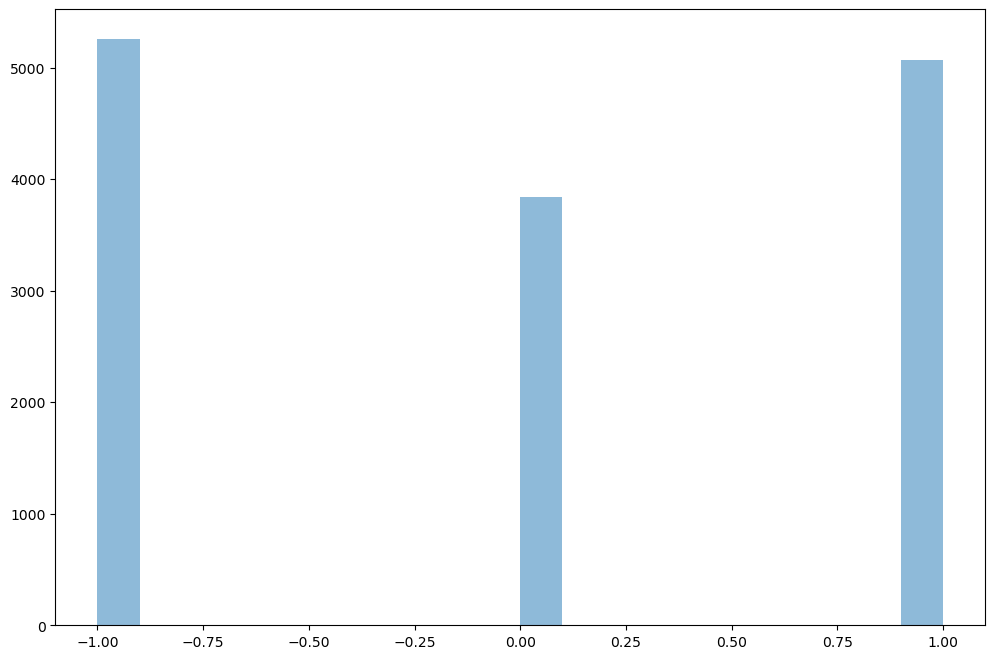

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))


for t in target:
    ax.hist(df_train[t], label=t, alpha=0.5, bins=20)

In [7]:
import sklearn


class DummyClassifier(sklearn.base.BaseEstimator):
    def __init__(self): ...

    def fit(self, X, y):
        pass

    def predict(self, X):
        return X.select(
            pl.when(pl.col("home_team") == 1)
            .then(1)
            .otherwise(-1)
            .alias("result_class_pred"),
        )


class GoalsMapper:
    def __init__(
        self,
        estimator: sklearn.base.BaseEstimator,
        suffix: str | None = None,
        threshold=0.5,
    ):
        self.estimator = estimator
        self.suffix = suffix

    def _calc_exact_result(self):
        return (
            pl.col("goals_team_1").cast(pl.String)
            + pl.lit(":")
            + pl.col("goals_team_2").cast(pl.String)
        )

    def _map_result_class(self):
        return pl.col("result_class_pred").replace_strict(
            self.result_class_map, default=self.fallback_exact_result
        )

    def _unpack_goals_pred(self):
        return (
            pl.col("exact_result_pred")
            .str.split(":")
            .list.to_struct(fields=["goals_team_1_pred", "goals_team_2_pred"])
        )

    def fit(self, X, y, goals):
        self.estimator.fit(X, y)

        df = pl.concat([goals, y], how="horizontal").with_columns(
            exact_result=self._calc_exact_result()
        )

        self.result_class_map = dict(
            df.group_by("result_class")
            .agg(pl.col("exact_result").mode())
            .explode("exact_result")
            .iter_rows()
        )
        self.fallback_exact_result = df["exact_result"].mode()

    def predict(self, X):
        y_pred = (
            pl.DataFrame(self.estimator.predict(X), schema=["result_class_pred"])
            .with_columns(exact_result_pred=self._map_result_class())
            .with_columns(goals_pred_struct=self._unpack_goals_pred())
            .unnest("goals_pred_struct")
            .with_columns(
                pl.col("goals_team_1_pred").cast(pl.Int64),
                pl.col("goals_team_2_pred").cast(pl.Int64),
            )
        )

        if self.suffix is not None:
            y_pred.columns = [col + self.suffix for col in y_pred.columns]

        return y_pred

In [8]:
dummy = GoalsMapper(DummyClassifier(), suffix="_dummy")
dummy.fit(df_train[train_cols], df_train[target], df_train[goals])
dummy.predict(df_train[train_cols])

result_class_pred_dummy,exact_result_pred_dummy,goals_team_1_pred_dummy,goals_team_2_pred_dummy
i32,str,i64,i64
-1,"""0:1""",0,1
-1,"""0:1""",0,1
-1,"""0:1""",0,1
1,"""2:1""",2,1
1,"""2:1""",2,1
…,…,…,…
-1,"""0:1""",0,1
-1,"""0:1""",0,1
1,"""2:1""",2,1


In [9]:
df_train = df_train.with_columns(dummy.predict(df_train[train_cols]))

In [10]:
df_test = df_test.with_columns(dummy.predict(df_test[train_cols]))

In [11]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_dummy"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.44      0.60      0.51      5259
           0       0.00      0.00      0.00      3837
           1       0.43      0.60      0.50      5070

    accuracy                           0.44     14166
   macro avg       0.29      0.40      0.34     14166
weighted avg       0.32      0.44      0.37     14166



In [12]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_dummy"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.46      0.62      0.53      1329
           0       0.00      0.00      0.00       918
           1       0.45      0.61      0.52      1295

    accuracy                           0.46      3542
   macro avg       0.30      0.41      0.35      3542
weighted avg       0.34      0.46      0.39      3542



In [13]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_dummy", "goals_team_2_pred_dummy"]]
)

np.float64(0.9583509812226457)

In [14]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_dummy", "goals_team_2_pred_dummy"]]
)

np.float64(1.0056465273856579)

In [15]:
mean_ak_score(
    df_train[goals],
    df_train.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
)

np.float64(0.9590568967951433)

In [16]:
mean_ak_score(
    df_test[goals],
    df_test.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
)

np.float64(1.002540937323546)

In [17]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(dummy.predict(df_2425[train_cols]))

In [18]:
mean_ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_dummy", "goals_team_2_pred_dummy"]]
)

np.float64(0.9797979797979798)

In [19]:
ak_score(
    df_2425[goals],
    df_2425.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
)

array([2, 2, 0, 0, 2, 2, 0, 0, 2, 0, 0, 2, 0, 0, 3, 2, 2, 2, 0, 3, 0, 0,
       3, 0, 0, 0, 3, 2, 2, 2, 0, 0, 2, 3, 0, 0, 2, 0, 0, 2, 3, 0, 0, 0,
       2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 3, 0, 0, 0, 0, 0, 2, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 3, 2, 0, 0, 3, 0, 0, 0, 0, 2, 3, 0, 2,
       0, 2, 0, 0, 0, 2, 2, 2, 2, 2, 0])

In [20]:
ak_score(
    df_2425[goals],
    df_2425.select(
        pl.when(pl.col("home_team") == 1)
        .then(2)
        .otherwise(1)
        .alias("goals_team_1_pred_dummy"),
        pl.when(pl.col("home_team") == 1)
        .then(1)
        .otherwise(2)
        .alias("goals_team_2_pred_dummy"),
    ),
).sum()

np.int64(98)

In [21]:
df_2425.with_columns(
    ak_score=ak_score(
        df_2425[goals],
        df_2425.select(
            pl.when(pl.col("home_team") == 1)
            .then(2)
            .otherwise(1)
            .alias("goals_team_1_pred_dummy"),
            pl.when(pl.col("home_team") == 1)
            .then(1)
            .otherwise(2)
            .alias("goals_team_2_pred_dummy"),
        ),
    )
).group_by("match_day").agg(pl.col("ak_score").sum()).sort("match_day")

match_day,ak_score
i64,i64
1,8
2,8
3,7
4,9
5,6
…,…
7,14
8,8
9,11


In [22]:
df_2425.with_columns(
    ak_score=ak_score(
        df_2425[goals],
        df_2425.select(
            pl.when(pl.col("home_team") == 1)
            .then(2)
            .otherwise(1)
            .alias("goals_team_1_pred_dummy"),
            pl.when(pl.col("home_team") == 1)
            .then(1)
            .otherwise(2)
            .alias("goals_team_2_pred_dummy"),
        ),
    )
)

match_id,league_id,match_day,team_id_1,team_name_1,team_id_2,team_name_2,goals_team_1,goals_team_2,goals_diff,result_class,home_team,games_1,rank_1,games_2,rank_2,rank_diff,wins_last_3_games_1,wins_last_5_games_1,wins_avg_1,draws_last_3_games_1,draws_last_5_games_1,draws_avg_1,losses_last_3_games_1,losses_last_5_games_1,losses_avg_1,points_last_3_games_1,points_last_5_games_1,points_avg_1,goals_scored_last_3_games_1,goals_scored_last_5_games_1,goals_scored_avg_1,goals_conceded_last_3_games_1,goals_conceded_last_5_games_1,goals_conceded_avg_1,goals_diff_last_3_games_1,goals_diff_last_5_games_1,goals_diff_avg_1,wins_last_3_games_2,wins_last_5_games_2,wins_avg_2,draws_last_3_games_2,draws_last_5_games_2,draws_avg_2,losses_last_3_games_2,losses_last_5_games_2,losses_avg_2,points_last_3_games_2,points_last_5_games_2,points_avg_2,goals_scored_last_3_games_2,goals_scored_last_5_games_2,goals_scored_avg_2,goals_conceded_last_3_games_2,goals_conceded_last_5_games_2,goals_conceded_avg_2,goals_diff_last_3_games_2,goals_diff_last_5_games_2,goals_diff_avg_2,result_class_pred_dummy,exact_result_pred_dummy,goals_team_1_pred_dummy,goals_team_2_pred_dummy,ak_score
i64,i64,i64,i64,str,i64,str,i64,i64,i64,i32,i32,i32,i64,i32,i64,i64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,str,i64,i64,i64
72217,4741,1,123,"""TSG 1899 Hoffenheim""",104,"""Holstein Kiel""",3,2,1,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""2:1""",2,1,2
72218,4741,1,112,"""SC Freiburg""",16,"""VfB Stuttgart""",3,1,2,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""2:1""",2,1,2
72219,4741,1,95,"""FC Augsburg""",134,"""Werder Bremen""",2,2,0,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""2:1""",2,1,0
72221,4741,1,81,"""1. FSV Mainz 05""",80,"""1. FC Union Berlin""",1,1,0,0,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""2:1""",2,1,0
72216,4741,1,7,"""Borussia Dortmund""",91,"""Eintracht Frankfurt""",2,0,2,1,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1,"""2:1""",2,1,2
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
72305,4741,11,129,"""VfL Bochum""",16,"""VfB Stuttgart""",0,2,-2,-1,0,10,18,10,11,7,0,0,0.0,1,1,0.2,2,4,0.8,1,1,0.2,3,5,1.0,13,19,3.0,-10,-14,-2.0,1,1,0.3,1,2,0.4,1,2,0.3,4,5,1.3,4,5,1.9,4,9,1.9,0,-4,0.0,-1,"""0:1""",0,1,2
72307,4741,11,112,"""SC Freiburg""",7,"""Borussia Dortmund""",0,4,-4,-1,0,10,5,10,7,-2,0,2,0.5,2,2,0.2,1,1,0.3,2,8,1.7,1,5,1.3,3,4,1.1,-2,1,0.2,1,2,0.5,0,0,0.1,2,3,0.4,3,6,1.6,4,7,1.8,6,9,1.8,-2,-2,0.0,-1,"""0:1""",0,1,2
72309,4741,11,1635,"""RB Leipzig""",123,"""TSG 1899 Hoffenheim""",3,4,-1,-1,0,10,2,10,15,-13,1,3,0.6,1,1,0.3,1,1,0.1,4,10,2.1,4,7,1.5,3,3,0.5,1,4,1.0,0,1,0.2,2,3,0.3,1,1,0.5,2,6,0.9,0,4,1.3,2,4,1.9,-2,0,-0.6,-1,"""0:1""",0,1,2


In [23]:
with pl.Config(tbl_rows=90):
    display(
        df_2425.with_columns(
            ak_score=ak_score(
                df_2425[goals],
                df_2425.select(
                    pl.when(pl.col("home_team") == 1)
                    .then(2)
                    .otherwise(1)
                    .alias("goals_team_1_pred_dummy"),
                    pl.when(pl.col("home_team") == 1)
                    .then(1)
                    .otherwise(2)
                    .alias("goals_team_2_pred_dummy"),
                ),
            )
        )
        .select(
            [
                "match_day",
                "team_name_1",
                "team_name_2",
                "home_team",
                "goals_team_1",
                "goals_team_2",
                "result_class",
                "ak_score",
            ]
        )
        .sort("match_day")
    )

match_day,team_name_1,team_name_2,home_team,goals_team_1,goals_team_2,result_class,ak_score
i64,str,str,i32,i64,i64,i32,i64
1,"""TSG 1899 Hoffenheim""","""Holstein Kiel""",1,3,2,1,2
1,"""SC Freiburg""","""VfB Stuttgart""",1,3,1,1,2
1,"""FC Augsburg""","""Werder Bremen""",1,2,2,0,0
1,"""1. FSV Mainz 05""","""1. FC Union Berlin""",1,1,1,0,0
1,"""Borussia Dortmund""","""Eintracht Frankfurt""",1,2,0,1,2
1,"""Bayer Leverkusen""","""Borussia Mönchengladbach""",0,3,2,1,0
1,"""VfL Bochum""","""RB Leipzig""",0,0,1,-1,2
1,"""FC Bayern München""","""VfL Wolfsburg""",0,3,2,1,0
1,"""1. FC Heidenheim 1846""","""FC St. Pauli""",0,2,0,1,0


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

logreg_base = LogisticRegression(max_iter=10000, C=10)
# ridge_base = Ridge(max_iter=10000, alpha=10)
# poisson_base = PoissonRegressor(max_iter=10000, alpha=10)
si = SimpleImputer()
ss = StandardScaler()
pipe = Pipeline([("impute", si), ("scale", ss), ("estimator", logreg_base)])

logreg = GoalsMapper(pipe, suffix="_logreg", threshold=0)
logreg.fit(df_train[train_cols], df_train[target], df_train[goals])

/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [25]:
importances_logreg = pl.DataFrame(
    {
        "feature": train_cols,
        "coef_win_team_1": logreg.estimator.named_steps["estimator"].coef_[0],
        "coef_draw": logreg.estimator.named_steps["estimator"].coef_[1],
        "coef_win_team_2": logreg.estimator.named_steps["estimator"].coef_[2],
    }
)
importances_logreg.sort("coef_win_team_1")

feature,coef_win_team_1,coef_draw,coef_win_team_2
str,f64,f64,f64
"""games_2""",-0.713848,0.906531,-0.192683
"""home_team""",-0.222538,-0.008447,0.230985
"""rank_1""",-0.177829,0.023889,0.15394
"""goals_diff_avg_1""",-0.044346,-0.032215,0.07656
"""goals_scored_avg_1""",-0.043584,-0.031746,0.07533
…,…,…,…
"""goals_diff_avg_2""",0.066674,-0.016977,-0.049697
"""goals_scored_avg_2""",0.068206,-0.034425,-0.033781
"""rank_2""",0.169884,-0.003192,-0.166692


In [26]:
df_train = df_train.with_columns(logreg.predict(df_train[train_cols]))

In [27]:
df_test = df_test.with_columns(logreg.predict(df_test[train_cols]))

In [28]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_logreg"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.47      0.65      0.54      5259
           0       0.46      0.01      0.01      3837
           1       0.46      0.62      0.53      5070

    accuracy                           0.47     14166
   macro avg       0.46      0.43      0.36     14166
weighted avg       0.46      0.47      0.39     14166



In [29]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_logreg"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.47      0.65      0.55      1329
           0       0.20      0.00      0.00       918
           1       0.47      0.62      0.54      1295

    accuracy                           0.47      3542
   macro avg       0.38      0.43      0.36      3542
weighted avg       0.40      0.47      0.40      3542



In [30]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_logreg", "goals_team_2_pred_logreg"]]
)

np.float64(1.0201891853734293)

In [31]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_logreg", "goals_team_2_pred_logreg"]]
)

np.float64(1.0338791643139469)

In [32]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(logreg.predict(df_2425[train_cols]))

In [33]:
ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_logreg", "goals_team_2_pred_logreg"]]
).sum()

np.int64(99)

In [34]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist = GoalsMapper(
    HistGradientBoostingClassifier(
        max_iter=3000,
        learning_rate=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42,
        max_leaf_nodes=8,
        min_samples_leaf=50,
    ),
    suffix="_hgbm",
)

hist.fit(df_train.select(train_cols), df_train.select(target), df_train[goals])

/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


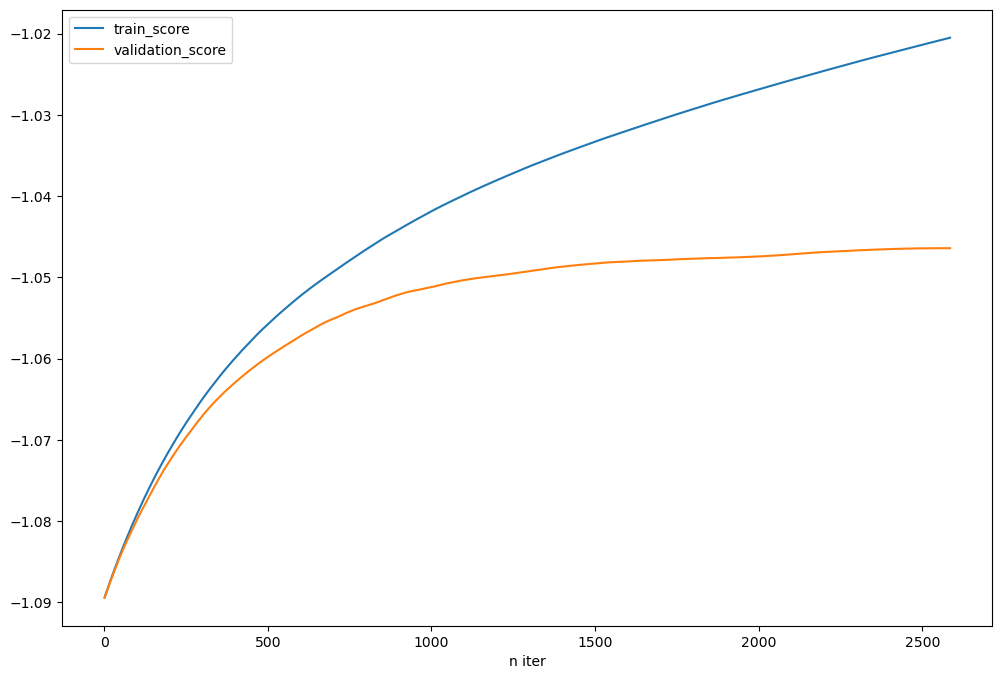

In [35]:
fig, ax = plt.subplots(figsize=(12, 8))

train_scores = hist.estimator.train_score_
validation_scores = hist.estimator.validation_score_
iter = range(1, len(train_scores) + 1)

ax.plot(iter, train_scores, label="train_score")
ax.plot(iter, validation_scores, label="validation_score")
ax.set_xlabel("n iter")
ax.legend();

In [36]:
df_train = df_train.with_columns(hist.predict(df_train[train_cols]))

In [37]:
df_test = df_test.with_columns(hist.predict(df_test[train_cols]))

In [38]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_hgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.48      0.66      0.56      5259
           0       0.55      0.03      0.06      3837
           1       0.48      0.63      0.54      5070

    accuracy                           0.48     14166
   macro avg       0.50      0.44      0.39     14166
weighted avg       0.50      0.48      0.42     14166



In [39]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_hgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.48      0.64      0.55      1329
           0       0.35      0.02      0.04       918
           1       0.47      0.61      0.53      1295

    accuracy                           0.47      3542
   macro avg       0.43      0.43      0.37      3542
weighted avg       0.44      0.47      0.41      3542



In [40]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_hgbm", "goals_team_2_pred_hgbm"]]
)

np.float64(1.0554849639983057)

In [41]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_hgbm", "goals_team_2_pred_hgbm"]]
)

np.float64(1.033596837944664)

In [42]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(hist.predict(df_2425[train_cols]))

In [43]:
ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_hgbm", "goals_team_2_pred_hgbm"]]
).sum()

np.int64(103)

In [44]:
from lightgbm import LGBMClassifier

lgbm = GoalsMapper(
    LGBMClassifier(
        n_estimators=3000, learning_rate=0.001, objective="multiclass", num_leaves=8
    ),
    suffix="_lgbm",
)

lgbm.fit(df_train.select(train_cols), df_train.select(target), df_train[goals])

/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:97: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/fabian/miniforge3/envs/AK-Tippspiel/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003295 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3991
[LightGBM] [Info] Number of data points in the train set: 14166, number of used features: 48
[LightGBM] [Info] Start training from score -0.990904
[LightGBM] [Info] Start training from score -1.306154
[LightGBM] [Info] Start training from score -1.027504


In [45]:
df_train = df_train.with_columns(lgbm.predict(df_train[train_cols]))

In [46]:
df_test = df_test.with_columns(lgbm.predict(df_test[train_cols]))

In [47]:
print(
    classification_report(
        df_train[target], df_train["result_class_pred_lgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.48      0.66      0.56      5259
           0       0.65      0.02      0.03      3837
           1       0.47      0.64      0.54      5070

    accuracy                           0.48     14166
   macro avg       0.54      0.44      0.38     14166
weighted avg       0.52      0.48      0.41     14166



In [48]:
print(
    classification_report(
        df_test[target], df_test["result_class_pred_lgbm"], zero_division=0
    )
)

              precision    recall  f1-score   support

          -1       0.48      0.65      0.55      1329
           0       0.25      0.01      0.01       918
           1       0.47      0.63      0.54      1295

    accuracy                           0.47      3542
   macro avg       0.40      0.43      0.37      3542
weighted avg       0.42      0.47      0.41      3542



In [49]:
mean_ak_score(
    df_train[goals], df_train[["goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]]
)

np.float64(1.0472257518000847)

In [50]:
mean_ak_score(
    df_test[goals], df_test[["goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]]
)

np.float64(1.0352907961603615)

In [51]:
df_2425 = df.filter(pl.col("league_id") == 4741)
df_2425 = df_2425.with_columns(lgbm.predict(df_2425[train_cols]))

In [52]:
ak_score(
    df_2425[goals], df_2425[["goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]]
).sum()

np.int64(100)

In [53]:
importances = pl.DataFrame(
    {"feature": train_cols, "importance": lgbm.estimator.feature_importances_}
)
importances.sort("importance", descending=True).head(10)

feature,importance
str,i32
"""home_team""",6095
"""goals_diff_avg_2""",4278
"""goals_scored_avg_1""",4202
"""games_1""",4169
"""goals_scored_avg_2""",4031
"""goals_diff_avg_1""",3745
"""rank_diff""",3414
"""points_avg_2""",2684
"""goals_diff_last_5_games_1""",2409


In [54]:
from sklearn.metrics import roc_auc_score

In [55]:
roc_auc_score(
    df_test["result_class"],
    lgbm.estimator.predict_proba(df_test[train_cols]),
    multi_class="ovr",
)

np.float64(0.6018402806035286)

In [56]:
df_predict = (
    pl.scan_parquet(
        "/home/fabian/Project-Data/AK-Tippspiel/openligadb/openligadb_result_class_predict.parquet"
    )
    .filter((pl.col("league_id") == 4741) & (pl.col("match_day") == 12))
    .collect()
)
df_predict

match_id,league_id,match_day,team_id_1,team_name_1,team_id_2,team_name_2,goals_team_1,goals_team_2,goals_diff,result_class,home_team,games_1,rank_1,games_2,rank_2,rank_diff,wins_last_3_games_1,wins_last_5_games_1,wins_avg_1,draws_last_3_games_1,draws_last_5_games_1,draws_avg_1,losses_last_3_games_1,losses_last_5_games_1,losses_avg_1,points_last_3_games_1,points_last_5_games_1,points_avg_1,goals_scored_last_3_games_1,goals_scored_last_5_games_1,goals_scored_avg_1,goals_conceded_last_3_games_1,goals_conceded_last_5_games_1,goals_conceded_avg_1,goals_diff_last_3_games_1,goals_diff_last_5_games_1,goals_diff_avg_1,wins_last_3_games_2,wins_last_5_games_2,wins_avg_2,draws_last_3_games_2,draws_last_5_games_2,draws_avg_2,losses_last_3_games_2,losses_last_5_games_2,losses_avg_2,points_last_3_games_2,points_last_5_games_2,points_avg_2,goals_scored_last_3_games_2,goals_scored_last_5_games_2,goals_scored_avg_2,goals_conceded_last_3_games_2,goals_conceded_last_5_games_2,goals_conceded_avg_2,goals_diff_last_3_games_2,goals_diff_last_5_games_2,goals_diff_avg_2
i64,i64,i64,i64,str,i64,str,i64,i64,i64,i32,i32,i32,i64,i32,i64,i64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i32,i32,f64,i64,i64,f64,i64,i64,f64,i64,i64,f64
72321,4741,12,98,"""FC St. Pauli""",104,"""Holstein Kiel""",0,0,0,null,1,11,16,11,17,-1,1,1,0.181818,0,1,0.181818,2,3,0.636364,3,4,0.727273,2,3,0.636364,3,5,1.272727,-1,-2,-0.636364,1,1,0.090909,0,0,0.181818,2,4,0.727273,3,3,0.454545,2,3,1.090909,5,9,2.545455,-3,-6,-1.454545
72313,4741,12,1635,"""RB Leipzig""",131,"""VfL Wolfsburg""",0,0,0,null,1,11,3,11,11,-8,0,2,0.545455,1,1,0.272727,2,2,0.181818,1,7,1.909091,4,9,1.636364,6,7,0.818182,-2,2,0.818182,2,2,0.363636,1,2,0.272727,0,1,0.363636,7,8,1.363636,5,7,1.818182,2,6,1.636364,3,1,0.181818
72317,4741,12,112,"""SC Freiburg""",87,"""Borussia Mönchengladbach""",0,0,0,null,1,11,7,11,6,1,0,1,0.454545,2,2,0.181818,1,2,0.363636,2,5,1.545455,0,4,1.181818,4,8,1.363636,-4,-4,-0.181818,2,3,0.454545,1,2,0.181818,0,0,0.363636,7,11,1.545455,6,10,1.545455,1,4,1.272727,5,6,0.272727
72318,4741,12,95,"""FC Augsburg""",129,"""VfL Bochum""",0,0,0,null,1,11,14,11,18,-4,0,1,0.272727,2,2,0.272727,1,2,0.454545,2,5,1.090909,1,4,1.181818,4,8,2.090909,-3,-4,-0.909091,0,0,0.0,1,1,0.181818,2,4,0.818182,1,1,0.181818,3,4,0.909091,10,18,2.909091,-7,-14,-2.0
72320,4741,12,80,"""1. FC Union Berlin""",6,"""Bayer Leverkusen""",0,0,0,null,1,11,10,11,4,6,0,1,0.363636,1,2,0.363636,2,2,0.272727,1,5,1.454545,0,3,0.818182,4,5,0.818182,-4,-2,0.0,1,2,0.454545,2,3,0.454545,0,0,0.090909,5,9,1.818182,6,10,2.363636,3,6,1.636364,3,4,0.727273
72319,4741,12,81,"""1. FSV Mainz 05""",123,"""TSG 1899 Hoffenheim""",0,0,0,null,1,11,8,11,13,-5,2,2,0.363636,1,2,0.363636,0,1,0.272727,7,8,1.454545,6,7,1.636364,1,4,1.272727,5,3,0.363636,1,2,0.272727,1,2,0.272727,1,1,0.454545,4,8,1.090909,4,7,1.545455,5,6,2.0,-1,1,-0.454545
72315,4741,12,199,"""1. FC Heidenheim 1846""",91,"""Eintracht Frankfurt""",0,0,0,null,1,11,15,11,2,13,0,0,0.272727,0,1,0.090909,3,4,0.636364,0,1,0.909091,3,5,1.363636,9,12,1.818182,-6,-7,-0.454545,3,3,0.636364,0,1,0.181818,0,1,0.181818,9,10,2.090909,11,13,2.454545,4,7,1.454545,7,6,1.0
72316,4741,12,16,"""VfB Stuttgart""",134,"""Werder Bremen""",0,0,0,null,0,11,9,11,12,-3,1,2,0.363636,1,1,0.363636,1,2,0.272727,4,7,1.454545,4,6,1.909091,3,8,1.727273,1,-2,0.181818,1,2,0.363636,0,1,0.272727,2,2,0.363636,3,7,1.363636,3,9,1.545455,6,10,2.0,-3,-1,-0.454545
72314,4741,12,40,"""FC Bayern München""",7,"""Borussia Dortmund""",0,0,0,null,0,11,1,11,5,-4,3,5,0.818182,0,0,0.181818,0,0,0.0,9,15,2.636364,7,16,3.272727,0,0,0.636364,7,16,2.636364,2,3,0.545455,0,0,0.090909,1,2,0.363636,6,9,1.727273,7,10,2.0,4,7,1.636364,3,3,0.363636


In [57]:
df_predict = df_predict.with_columns(lgbm.predict(df_predict[train_cols]))
df_predict.select(
    ["team_name_1", "team_name_2", "goals_team_1_pred_lgbm", "goals_team_2_pred_lgbm"]
)

team_name_1,team_name_2,goals_team_1_pred_lgbm,goals_team_2_pred_lgbm
str,str,i64,i64
"""FC St. Pauli""","""Holstein Kiel""",2,1
"""RB Leipzig""","""VfL Wolfsburg""",2,1
"""SC Freiburg""","""Borussia Mönchengladbach""",2,1
"""FC Augsburg""","""VfL Bochum""",2,1
"""1. FC Union Berlin""","""Bayer Leverkusen""",0,1
"""1. FSV Mainz 05""","""TSG 1899 Hoffenheim""",2,1
"""1. FC Heidenheim 1846""","""Eintracht Frankfurt""",0,1
"""VfB Stuttgart""","""Werder Bremen""",0,1
"""FC Bayern München""","""Borussia Dortmund""",2,1
